# Agentic RAG with LangGraph

In [9]:
import os
from typing import TypedDict, List

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from dotenv import load_dotenv

In [2]:
import os
from dotenv import load_dotenv

load_dotenv(r"D:\RAG\notebook\.env")

print(bool(os.getenv("OPENAI_API_KEY")))

True


In [3]:
# Set your OpenAI API key

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

#Initialize models
llm=ChatOpenAI(model="gpt-4o-mini",temperature=0)
embeddings=OpenAIEmbeddings()

In [4]:
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-openai': '1.6.2'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002AC15DBD3C0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002AC305CD300>, root_client=<openai.OpenAI object at 0x000002AC15DBC820>

# State Definition

In [10]:
class AgentState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    needs_retrieval: bool

In [11]:
### Sample Document And VectorStore

sample_texts=[
    "LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures."
    "Retrieval-Augmented Generation (RAG) is an AI framework that improves large language model (LLM) responses by fetching relevant data from external, authoritative sources before generating an answer"
    "A vector database stores, manages and indexes high-dimensional vector data.In a vector database, data points are stored as arrays of numbers called “vectors,” which can be compared and clustered based on similarity."
    "Traditional AI just answers questions or writes text when you type a prompt. Agentic AI goes much further. It plans steps, makes decisions, and uses outside tools to finish real-world jobs."
]
documents=[Document(page_content=text) for text in sample_texts]

#create vector store

vectorstore=FAISS.from_documents(documents,embeddings)
retriever=vectorstore.as_retriever(k=3)

# Agents Function

In [12]:
def decide_retrieval(state: AgentState) -> AgentState:
    """
    Decide if we need to retrieve documents based on the question
    """

    question=state["question"]

    #Simple heuristic: if question contain certain keywords, retrieve
    retrieval_keywords=["what","how","explain","describe","tell me"]
    needs_retrieval=any(keyword in question.lower() for keyword in retrieval_keywords)

    return {**state,"needs_retrieval":needs_retrieval}

In [13]:
def retrieve_documents(state:AgentState) -> AgentState:
    """
    Retrieve relevant documents based on the question
    """
    question=state["question"]
    documents=retriever.invoke(question)

    return {**state, "documents":documents}

In [22]:
def generate_answer(state: AgentState) -> AgentState:
    """
    Generate an answer using the retrieved documents or direct response
    """
    question=state["question"]
    documents=state.get("documents",[])

    if documents:
        #RAG approach: use documents as context
        context="\n\n".join(doc.page_content for doc in documents)
        prompt=f"""Based on the following context, answer the question
Context:
{context}

Question:{question}

Answer:"""
    else:
        # Direct response without retrieval
        prompt=f"Answer the following question: {question}"

    response=llm.invoke(prompt)
    answer=response.content

    return {**state, "answer":answer}

# Conditional Logic

In [23]:
def should_retrieve(state: AgentState) -> str:
    """
    Determine the next step based on retrieval decision
    """
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

# Build the Graph

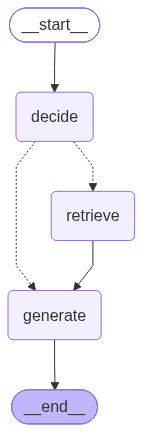

In [24]:
# Create the state graph

workflow= StateGraph(AgentState)

#Add nodes
workflow.add_node("decide",decide_retrieval)
workflow.add_node("retrieve",retrieve_documents)
workflow.add_node("generate",generate_answer)

# Set entry point
workflow.set_entry_point("decide")

# Add conditional edges
workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve":"retrieve",
        "generate":"generate"
    }
)

# Add edges
workflow.add_edge("retrieve","generate")
workflow.add_edge("generate",END)

# Compile the graph
app=workflow.compile()
app

# Test the Agentic System

In [25]:
def ask_question(question: str):
    """
    Helper function to ask a question and get an answer
    """
    inital_state={
        "question":question,
        "documents":[],
        "answer":"",
        "needs_retrieval":False
    }

    result=app.invoke(inital_state)
    return result

In [26]:
# Test with a question that should trigger retrieval

question1="What is LangGraph?"
result1=ask_question(question1)
result1

{'question': 'What is LangGraph?',
 'documents': [Document(id='0f8393e5-de24-4de0-a000-b75828bbe497', metadata={}, page_content='LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures.Retrieval-Augmented Generation (RAG) is an AI framework that improves large language model (LLM) responses by fetching relevant data from external, authoritative sources before generating an answerA vector database stores, manages and indexes high-dimensional vector data.In a vector database, data points are stored as arrays of numbers called “vectors,” which can be compared and clustered based on similarity.Traditional AI just answers questions or writes text when you type a prompt. Agentic AI goes much further. It plans steps, makes decisions, and uses outside tools to finish real-world jobs.')],
 'answer': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based stru

In [27]:
print("LLM test starting...")

response = llm.invoke("What is LangGraph? Answer in one short sentence.")

print("LLM test completed!")
print(response.content)

LLM test starting...
LLM test completed!
LangGraph is a framework designed for building and deploying applications that leverage large language models and graph-based data structures.


In [28]:
# Test with another question

question2="How does Rag work?"
result2=ask_question(question2)

print(f"Question:{question2}")
print(f"Retrieved documents: {len(result2['documents'])}")
print(f"Answer: {result2['answer']}")
print("\n" + "="*50 + "\n")

Question:How does Rag work?
Retrieved documents: 1
Answer: Retrieval-Augmented Generation (RAG) works by enhancing the responses of large language models (LLMs) through a two-step process. First, it retrieves relevant data from external, authoritative sources, which can include databases, documents, or other information repositories. This retrieval is typically facilitated by a vector database that stores data points as high-dimensional vectors, allowing for efficient comparison and clustering based on similarity.

Once the relevant information is fetched, the LLM then generates a response by incorporating this external data into its answer. This approach allows RAG to provide more accurate and contextually relevant responses, as it leverages up-to-date and specific information rather than relying solely on the model's pre-existing knowledge. Overall, RAG combines the strengths of information retrieval and generative capabilities to improve the quality of AI-generated responses.


